In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

## Task 1 – Dataset Understanding

In [12]:
df = pd.read_csv('adult.csv')

expected_cols = ['age','workclass','fnlwgt','education','education-num',
                 'marital-status','occupation','relationship','race','sex',
                 'capital-gain','capital-loss','hours-per-week','native-country','income']
if list(df.columns) != expected_cols:
    df.columns = expected_cols

print("Shape:", df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [14]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [16]:
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.92 %
>50K     24.08 %
Name: proportion, dtype: str


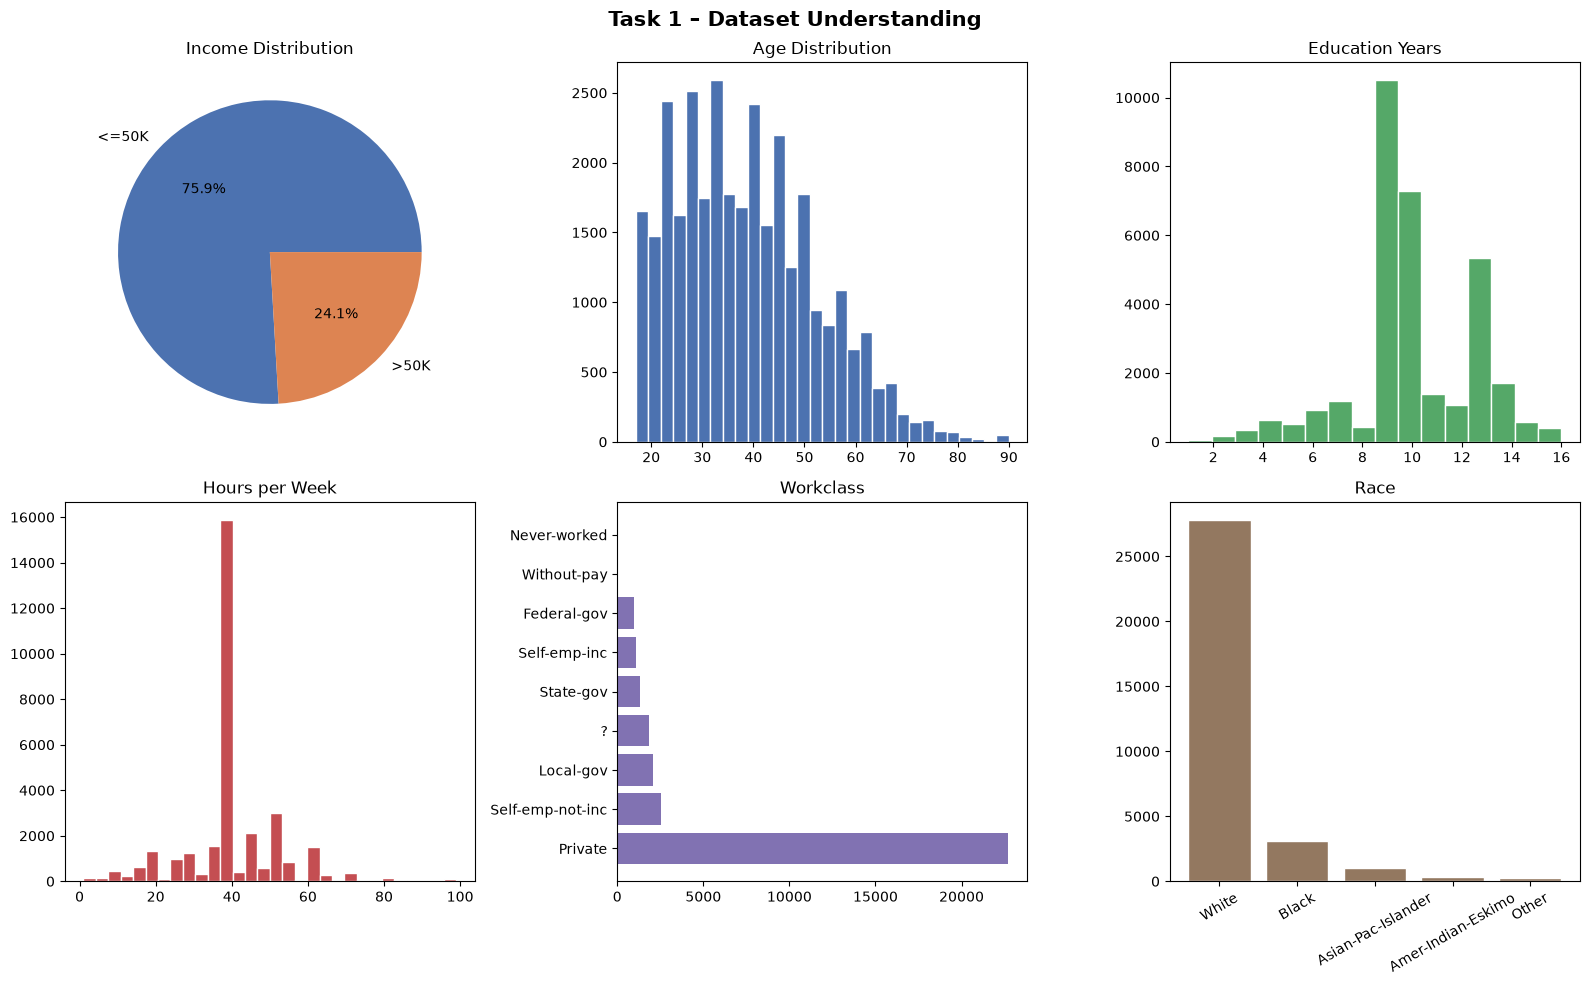

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Task 1 – Dataset Understanding', fontsize=15, fontweight='bold')

income_counts = df['income'].value_counts()
axes[0,0].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%',
              colors=['#4C72B0','#DD8452'])
axes[0,0].set_title('Income Distribution')

axes[0,1].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,1].set_title('Age Distribution')

axes[0,2].hist(df['education-num'], bins=16, color='#55A868', edgecolor='white')
axes[0,2].set_title('Education Years')

axes[1,0].hist(df['hours-per-week'], bins=30, color='#C44E52', edgecolor='white')
axes[1,0].set_title('Hours per Week')

wc = df['workclass'].value_counts()
axes[1,1].barh(wc.index, wc.values, color='#8172B2')
axes[1,1].set_title('Workclass')

rc = df['race'].value_counts()
axes[1,2].bar(rc.index, rc.values, color='#937860', edgecolor='white')
axes[1,2].set_title('Race')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('task1_understanding.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2 – Data Cleaning

In [18]:
df.replace(' ?', np.nan, inplace=True)
df.replace('?',  np.nan, inplace=True)

print("Missing before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing before cleaning:
workclass         1836
occupation        1843
native-country     583
dtype: int64


In [19]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

missing_after = df.isnull().sum()
print("Missing after cleaning:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "No missing values.")

Missing after cleaning:
workclass         1836
occupation        1843
native-country     583
dtype: int64


In [20]:
dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {dupes} | Shape: {df.shape}")

Duplicates removed: 24 | Shape: (32537, 15)


In [21]:
def cap_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    return s.clip(Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1))

for col in ['age','hours-per-week','capital-gain','capital-loss']:
    df[col] = cap_outliers(df[col])

df['income'] = df['income'].str.replace('.','',regex=False).str.strip()
print("Unique income labels:", df['income'].unique())
print("Final shape:", df.shape)

Unique income labels: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Final shape: (32537, 15)


## Task 3 – Feature Engineering

In [22]:
le_target = LabelEncoder()
df['income_encoded'] = le_target.fit_transform(df['income'])
print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

{'<=50K': np.int64(0), '>50K': np.int64(1)}


In [23]:
df['capital-net']    = df['capital-gain'] - df['capital-loss']
df['age-group']      = pd.cut(df['age'], bins=[0,25,45,65,100],
                               labels=['Youth','Adult','MidAge','Senior'])
df['is-married']     = df['marital-status'].apply(
    lambda x: 1 if 'Married' in str(x) and 'not' not in str(x).lower() else 0)
df['high-education'] = (df['education-num'] >= 13).astype(int)

print("New features: capital-net, age-group, is-married, high-education")

New features: capital-net, age-group, is-married, high-education


In [24]:
cat_cols = ['workclass','education','marital-status','occupation',
            'relationship','race','sex','native-country','age-group']
num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss',
            'capital-net','hours-per-week','is-married','high-education']

df_model = df[cat_cols + num_cols + ['income_encoded']].copy()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop('income_encoded', axis=1)
y = df_model['income_encoded']
print("Feature matrix:", X.shape)

Feature matrix: (32537, 18)


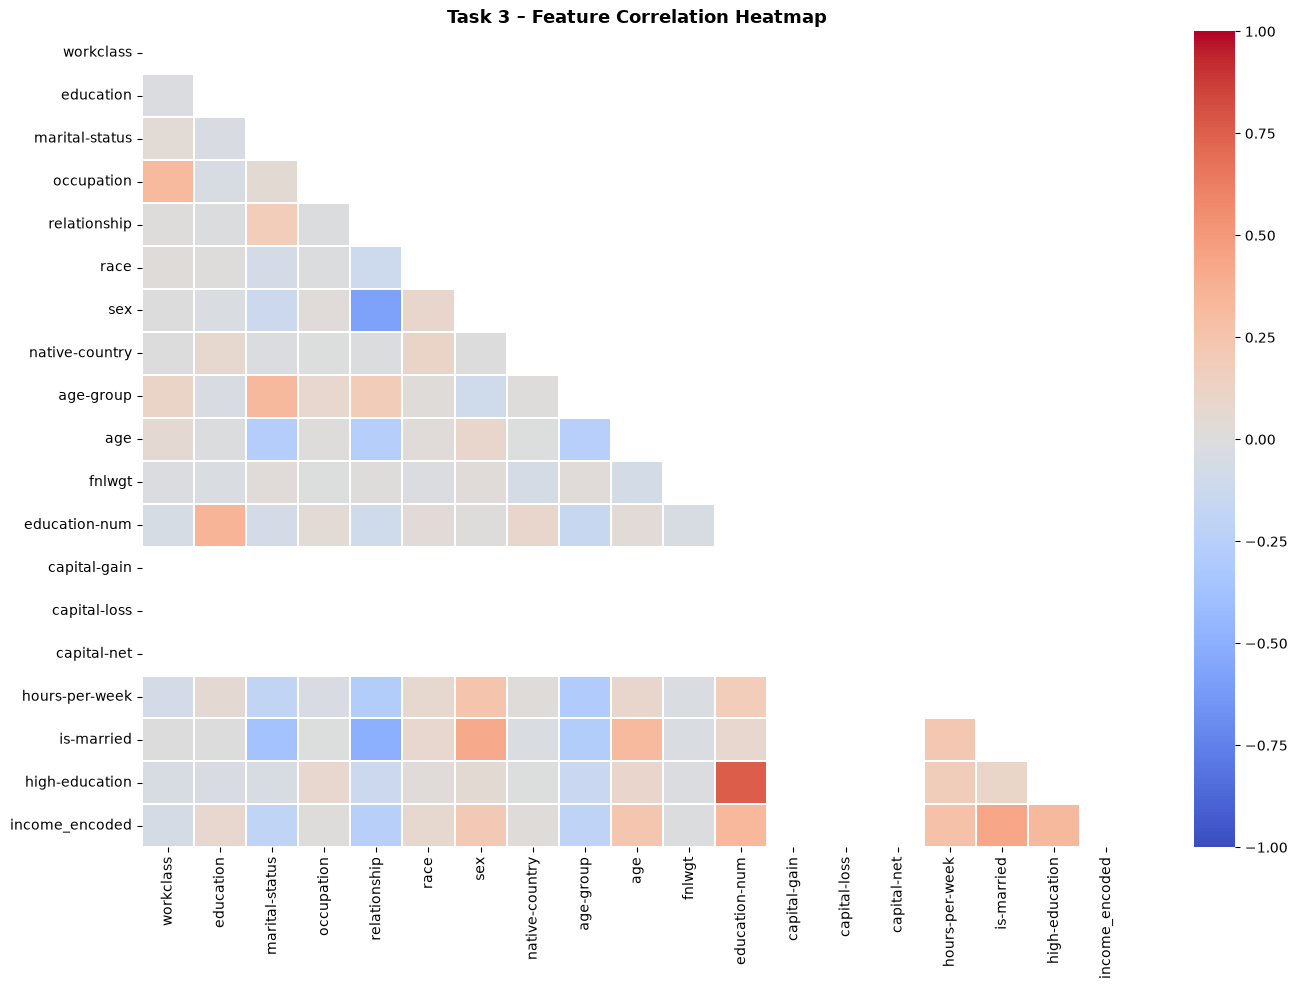

In [25]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df_model.corr(), dtype=bool))
sns.heatmap(df_model.corr(), mask=mask, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Task 3 – Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4 – Model Building

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 26029 | Test: 6508


In [27]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=7),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
}

results, conf_mats = {}, {}
scaled_models = {'Logistic Regression', 'KNN', 'SVM'}

for name, model in models.items():
    Xtr = X_train_sc if name in scaled_models else X_train.values
    Xte = X_test_sc  if name in scaled_models else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    }
    conf_mats[name] = confusion_matrix(y_test, y_pred)
    r = results[name]
    print(f"{name:<22} Acc={r['Accuracy']}  F1={r['F1 Score']}  AUC={r['ROC-AUC']}")

Logistic Regression    Acc=0.8267  F1=0.5957  AUC=0.8737
Decision Tree          Acc=0.8254  F1=0.6208  AUC=0.8504
Random Forest          Acc=0.8231  F1=0.6094  AUC=0.8645
KNN                    Acc=0.8161  F1=0.5976  AUC=0.8392
SVM                    Acc=0.8245  F1=0.5641  AUC=0.8499


## Task 5 – Performance Evaluation

In [28]:
results_df = pd.DataFrame(results).T
results_df.to_csv('performance_metrics.csv')
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.8267,0.6800,0.5300,0.5957,0.8737
Decision Tree,0.8254,0.6513,0.5931,0.6208,0.8504
Random Forest,0.8231,0.6512,0.5727,0.6094,0.8645
KNN,0.8161,0.6318,0.5670,0.5976,0.8392
SVM,0.8245,0.7025,0.4713,0.5641,0.8499


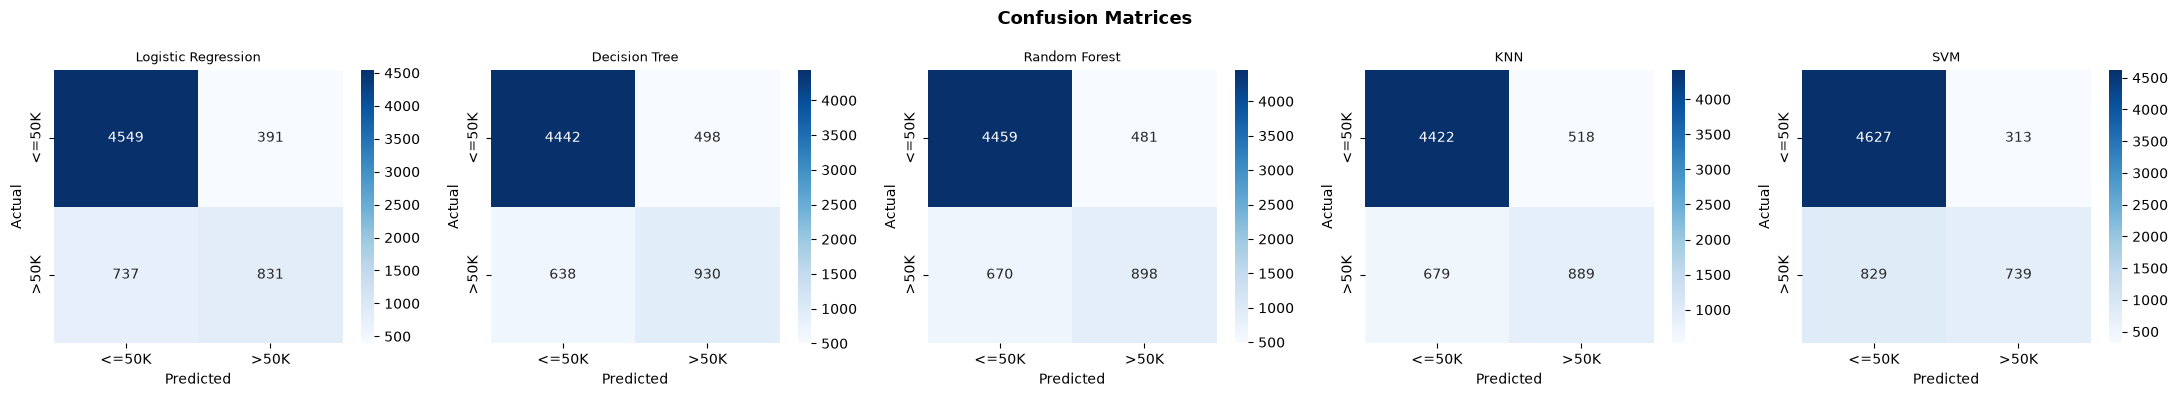

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
for ax, (name, cm) in zip(axes, conf_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('task5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

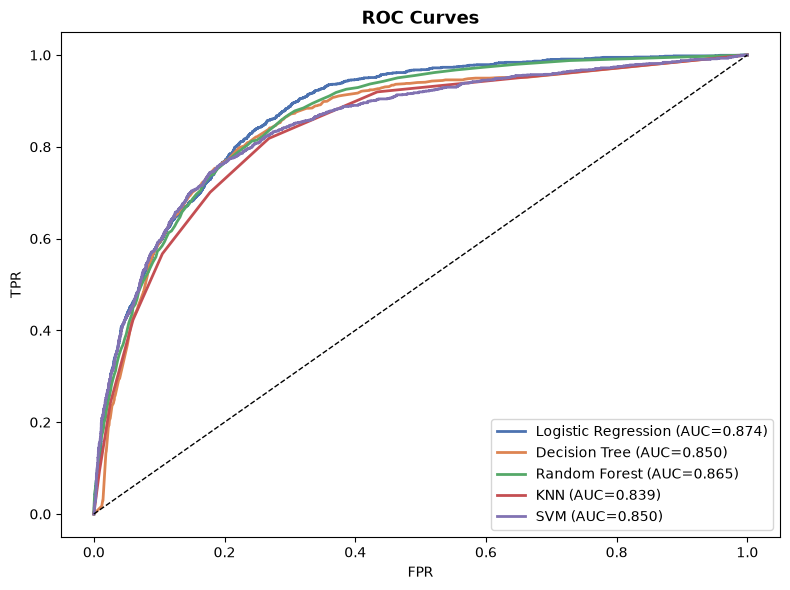

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
for (name, model), color in zip(models.items(), colors):
    Xte    = X_test_sc if name in scaled_models else X_test.values
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('task5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

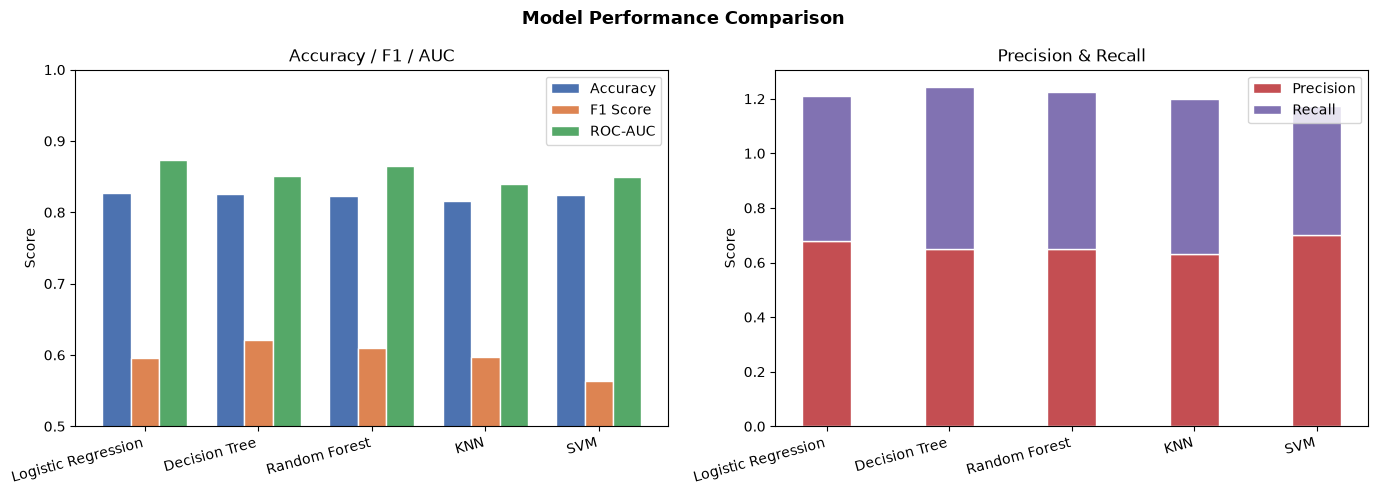

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

x, w = np.arange(len(results_df)), 0.25
for i, (metric, color) in enumerate(zip(['Accuracy','F1 Score','ROC-AUC'],
                                         ['#4C72B0','#DD8452','#55A868'])):
    axes[0].bar(x + i*w, results_df[metric], w, label=metric,
                color=color, edgecolor='white')
axes[0].set_xticks(x + w); axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel('Score'); axes[0].legend()
axes[0].set_title('Accuracy / F1 / AUC')

axes[1].bar(results_df.index, results_df['Precision'], 0.4,
            label='Precision', color='#C44E52', edgecolor='white')
axes[1].bar(results_df.index, results_df['Recall'], 0.4,
            bottom=results_df['Precision'], label='Recall',
            color='#8172B2', edgecolor='white')
axes[1].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[1].set_ylabel('Score'); axes[1].legend()
axes[1].set_title('Precision & Recall')

plt.tight_layout()
plt.savefig('task5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
best = results_df['Accuracy'].idxmax()
print(f"Best Model : {best}")
print(results_df.loc[best])

Best Model : Logistic Regression
Accuracy     0.8267
Precision    0.6800
Recall       0.5300
F1 Score     0.5957
ROC-AUC      0.8737
Name: Logistic Regression, dtype: float64
